# RiNALMo signal/noise: PCA k selection + large-window run detection

**Part 1**: Sweep PCA components (k=8..128) for signal/noise AUC.
Find the smallest k that gives strong separation.

**Part 2**: Instead of 72nt windows (RNA-FM approach), embed a large region
once with RiNALMo, get per-position signal scores, and find contiguous
"runs" of signal — exploiting context-stable embeddings.

Baseline: RNA-FM PCA(16) → LogReg AUC = 0.984

In [1]:
import sys, random, gc
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedShuffleSplit

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "modules" / "RiNALMo"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "RNA-FM"))
sys.path.insert(0, str(REPO_ROOT / "modules" / "pipeline"))

import short_ncrna as sn
from pyrion import TwoBitAccessor
from pyrion.io.bed import read_bed12_file

SEED = 42
random.seed(SEED); np.random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)

Device: mps


In [2]:
# --- Load RiNALMo + RNA-FM ---
from rinalmo.pretrained import get_pretrained_model
rin_model, rin_alpha = get_pretrained_model(model_name="giga-v1")
rin_model = rin_model.to(device).eval()

def emb_rinalmo(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    tokens = torch.tensor(
        rin_alpha.batch_tokenize([rna]), dtype=torch.int64, device=device
    )
    with torch.no_grad():
        out = rin_model(tokens)
    return out["representation"][0, 1:1 + len(rna), :].cpu().float().numpy()

import fm
fm_model, fm_alpha = fm.pretrained.rna_fm_t12()
fm_model.eval().to(device)
fm_bc = fm_alpha.get_batch_converter()

def emb_rnafm(seq: str) -> np.ndarray:
    rna = seq.upper().replace("T", "U")
    _, _, tk = fm_bc([("x", rna)])
    tk = tk.to(device)
    with torch.no_grad():
        out = fm_model(tk, repr_layers=[12])["representations"][12]
    return out[0, 1:1 + len(rna), :].cpu().float().numpy()

print("Both models loaded")

Both models loaded


In [3]:
# --- Extract signal + noise windows (72nt, same as pipeline) ---
WINDOW_SIZE = 72
N_SIGNAL = 500
N_NOISE = 500

BED_PATH    = REPO_ROOT / "input_data" / "reference_annotation" / "hg38.input.w.tRNA.bed"
TWOBIT_PATH = REPO_ROOT / "input_data" / "2bit" / "hg38.2bit"
META_PATH   = REPO_ROOT / "input_data" / "reference_annotation" / "test_sample.metadata.tsv"

accessor = TwoBitAccessor(str(TWOBIT_PATH))
bed_data = read_bed12_file(str(BED_PATH))
meta_df  = pd.read_csv(META_PATH, sep="\t")
biotype_map = dict(zip(meta_df["transcript_id"], meta_df["transcript_biotype"]))

SIGNAL_BIOTYPES = {"tRNA", "snoRNA", "miRNA", "snRNA", "misc_RNA", "scaRNA"}
rng = random.Random(SEED)

signal_windows = []
for t in bed_data:
    bt = "tRNA" if (t.id.startswith("tRNA-") and "Und-NNN" not in t.id) else biotype_map.get(t.id.split(".")[0])
    if bt not in SIGNAL_BIOTYPES:
        continue
    seq = sn._get_spliced_sequence(t, accessor)
    if not seq or "N" in seq.upper() or len(seq) < WINDOW_SIZE:
        continue
    seq = seq.upper().replace("T", "U")
    start = rng.randint(0, len(seq) - WINDOW_SIZE)
    signal_windows.append((seq[start:start + WINDOW_SIZE], bt))

rng.shuffle(signal_windows)
signal_windows = signal_windows[:N_SIGNAL]

# Noise
chrom_sizes = {}
for i in list(range(1, 23)) + ["X", "Y"]:
    chrom_sizes[f"chr{i}"] = 200_000_000
chroms = list(chrom_sizes.keys())

noise_windows = []
rng_n = random.Random(SEED + 1)
while len(noise_windows) < N_NOISE:
    chrom = rng_n.choice(chroms)
    start = rng_n.randint(0, chrom_sizes[chrom] - WINDOW_SIZE)
    try:
        seq = str(accessor.fetch(chrom, start, start + WINDOW_SIZE)).upper().replace("T", "U")
        if "N" not in seq and len(seq) == WINDOW_SIZE:
            noise_windows.append(seq)
    except:
        continue

all_seqs = [s for s, _ in signal_windows] + noise_windows
y = np.array([1] * len(signal_windows) + [0] * len(noise_windows))
print(f"Signal: {len(signal_windows)}, Noise: {len(noise_windows)}, Total: {len(all_seqs)}")

Signal: 500, Noise: 500, Total: 1000


In [4]:
# --- Embed all windows with both models (per-token) ---
print("Embedding with RiNALMo...")
rin_tok_embs = []  # list of (72, 1280) arrays
for i, seq in enumerate(all_seqs):
    rin_tok_embs.append(emb_rinalmo(seq))
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(all_seqs)}")

print("\nEmbedding with RNA-FM...")
fm_tok_embs = []  # list of (72, 640) arrays
for i, seq in enumerate(all_seqs):
    fm_tok_embs.append(emb_rnafm(seq))
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(all_seqs)}")

# Mean-pool for the window-level classifier
rin_mean = np.vstack([e.mean(axis=0) for e in rin_tok_embs]).astype(np.float32)
fm_mean = np.vstack([e.mean(axis=0) for e in fm_tok_embs]).astype(np.float32)
print(f"\nRiNALMo: {rin_mean.shape}, RNA-FM: {fm_mean.shape}")

Embedding with RiNALMo...
  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000

Embedding with RNA-FM...
  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000

RiNALMo: (1000, 1280), RNA-FM: (1000, 640)


## Part 1: PCA k sweep — what k gives good signal/noise AUC?

Sweep k = 8, 16, 32, 48, 64, 96, 128 for RiNALMo.
Also test raw (no PCA) as upper bound.
RNA-FM at k=16 as baseline.

In [5]:
K_VALUES = [8, 16, 32, 48, 64, 96, 128]

# Stratified 80/20 split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(sss.split(y, y))

sweep_rows = []

# --- RNA-FM baseline at k=16 ---
pca_fm = PCA(n_components=16).fit(fm_mean[train_idx])
X_fm = pca_fm.transform(fm_mean)
lr_fm = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
lr_fm.fit(X_fm[train_idx], y[train_idx])
auc_fm = roc_auc_score(y[test_idx], lr_fm.predict_proba(X_fm[test_idx])[:, 1])
var_fm = pca_fm.explained_variance_ratio_.sum()
sweep_rows.append({"model": "RNA-FM", "k": 16, "var_explained": var_fm, "test_auc": auc_fm})
print(f"RNA-FM k=16: var={var_fm:.3f}, AUC={auc_fm:.4f}")

# --- RiNALMo sweep ---
for k in K_VALUES:
    pca_k = PCA(n_components=k).fit(rin_mean[train_idx])
    X_k = pca_k.transform(rin_mean)
    lr_k = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
    lr_k.fit(X_k[train_idx], y[train_idx])
    auc_k = roc_auc_score(y[test_idx], lr_k.predict_proba(X_k[test_idx])[:, 1])
    var_k = pca_k.explained_variance_ratio_.sum()
    sweep_rows.append({"model": "RiNALMo", "k": k, "var_explained": var_k, "test_auc": auc_k})
    print(f"RiNALMo k={k:>3d}: var={var_k:.3f}, AUC={auc_k:.4f}")

# --- RiNALMo raw (no PCA) as upper bound ---
lr_raw = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
lr_raw.fit(rin_mean[train_idx], y[train_idx])
auc_raw = roc_auc_score(y[test_idx], lr_raw.predict_proba(rin_mean[test_idx])[:, 1])
sweep_rows.append({"model": "RiNALMo", "k": 1280, "var_explained": 1.0, "test_auc": auc_raw})
print(f"RiNALMo raw (1280): AUC={auc_raw:.4f}")

sweep_df = pd.DataFrame(sweep_rows)
print("\n" + sweep_df.to_string(index=False))

RNA-FM k=16: var=0.849, AUC=0.9837
RiNALMo k=  8: var=0.745, AUC=0.9424
RiNALMo k= 16: var=0.845, AUC=0.9733
RiNALMo k= 32: var=0.912, AUC=0.9723
RiNALMo k= 48: var=0.941, AUC=0.9658
RiNALMo k= 64: var=0.956, AUC=0.9615
RiNALMo k= 96: var=0.972, AUC=0.9610
RiNALMo k=128: var=0.980, AUC=0.9530
RiNALMo raw (1280): AUC=0.9603

  model    k  var_explained  test_auc
 RNA-FM   16       0.849262    0.9837
RiNALMo    8       0.745481    0.9424
RiNALMo   16       0.844730    0.9733
RiNALMo   32       0.912013    0.9723
RiNALMo   48       0.940766    0.9658
RiNALMo   64       0.955979    0.9615
RiNALMo   96       0.971605    0.9610
RiNALMo  128       0.980049    0.9530
RiNALMo 1280       1.000000    0.9603


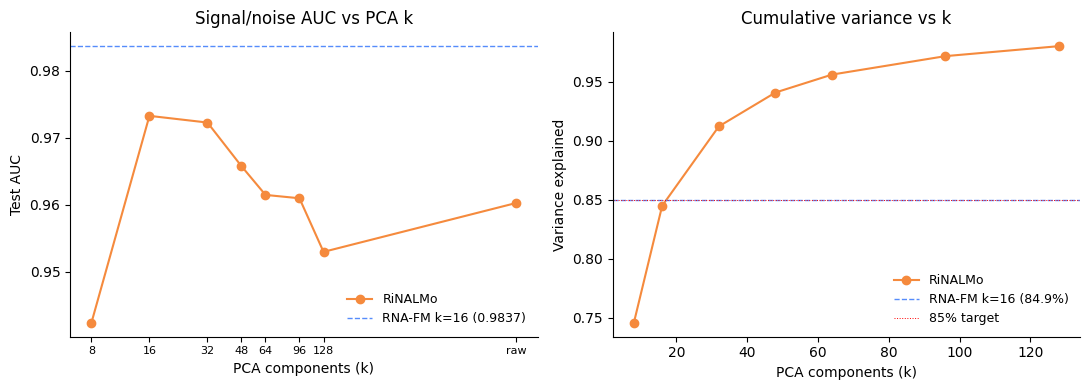

In [6]:
# --- Plot: AUC vs k ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

rin_sweep = sweep_df[sweep_df.model == "RiNALMo"]
ax1.plot(rin_sweep["k"], rin_sweep["test_auc"], "o-", color="C1", label="RiNALMo")
ax1.axhline(auc_fm, color="C0", ls="--", lw=1, label=f"RNA-FM k=16 ({auc_fm:.4f})")
ax1.set_xlabel("PCA components (k)")
ax1.set_ylabel("Test AUC")
ax1.set_title("Signal/noise AUC vs PCA k")
ax1.set_xscale("log", base=2)
ax1.set_xticks(K_VALUES + [1280])
ax1.set_xticklabels([str(k) for k in K_VALUES] + ["raw"], fontsize=8)
ax1.legend(frameon=False, fontsize=9)
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)

# Variance explained vs k
ax2.plot(rin_sweep["k"][:-1], rin_sweep["var_explained"][:-1], "o-", color="C1", label="RiNALMo")
ax2.axhline(var_fm, color="C0", ls="--", lw=1, label=f"RNA-FM k=16 ({var_fm:.1%})")
ax2.axhline(0.85, color="red", ls=":", lw=0.7, label="85% target")
ax2.set_xlabel("PCA components (k)")
ax2.set_ylabel("Variance explained")
ax2.set_title("Cumulative variance vs k")
ax2.legend(frameon=False, fontsize=9)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()

Chosen k = 16
  AUC = 0.9733 (raw = 0.9603, RNA-FM = 0.9837)
  Variance explained = 84.5%


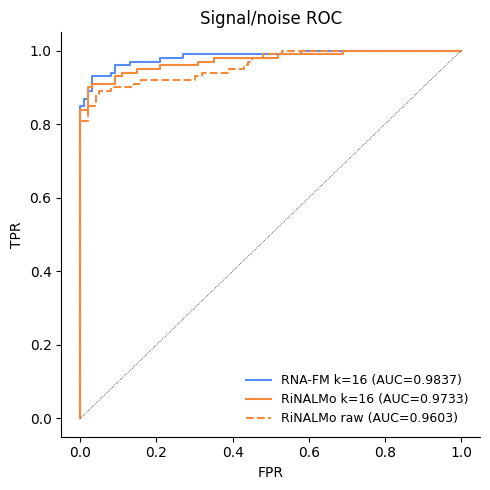

In [7]:
# --- Pick the best k and show ROC curves ---
# Choose smallest k where AUC is within 0.005 of raw
rin_only = sweep_df[(sweep_df.model == "RiNALMo") & (sweep_df.k < 1280)]
best_raw = auc_raw
tolerance = 0.005
good_k = rin_only[rin_only.test_auc >= best_raw - tolerance]
chosen_k = int(good_k["k"].min()) if len(good_k) > 0 else int(rin_only.loc[rin_only.test_auc.idxmax(), "k"])
chosen_auc = float(rin_only[rin_only.k == chosen_k]["test_auc"].values[0])
chosen_var = float(rin_only[rin_only.k == chosen_k]["var_explained"].values[0])

print(f"Chosen k = {chosen_k}")
print(f"  AUC = {chosen_auc:.4f} (raw = {best_raw:.4f}, RNA-FM = {auc_fm:.4f})")
print(f"  Variance explained = {chosen_var:.1%}")

# ROC curves
fig, ax = plt.subplots(figsize=(5, 5))

# RNA-FM k=16
fpr, tpr, _ = roc_curve(y[test_idx], lr_fm.predict_proba(X_fm[test_idx])[:, 1])
ax.plot(fpr, tpr, label=f"RNA-FM k=16 (AUC={auc_fm:.4f})", color="C0")

# RiNALMo chosen k
pca_chosen = PCA(n_components=chosen_k).fit(rin_mean[train_idx])
X_chosen = pca_chosen.transform(rin_mean)
lr_chosen = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
lr_chosen.fit(X_chosen[train_idx], y[train_idx])
fpr, tpr, _ = roc_curve(y[test_idx], lr_chosen.predict_proba(X_chosen[test_idx])[:, 1])
ax.plot(fpr, tpr, label=f"RiNALMo k={chosen_k} (AUC={chosen_auc:.4f})", color="C1")

# RiNALMo raw
fpr, tpr, _ = roc_curve(y[test_idx], lr_raw.predict_proba(rin_mean[test_idx])[:, 1])
ax.plot(fpr, tpr, label=f"RiNALMo raw (AUC={auc_raw:.4f})", color="C1", ls="--")

ax.plot([0, 1], [0, 1], "k:", lw=0.5)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Signal/noise ROC")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## Part 2: Large-window signal run detection

Instead of re-embedding many 72nt windows, embed a long region once,
then classify each position using a sliding window over the per-token
embeddings (just numpy slicing — free).

Pipeline: embed full region → slide a window over token embeddings →
mean-pool each window → PCA → LogReg score → smooth → threshold → find runs.

Test on real ncRNAs embedded within genomic flanking context.

In [8]:
# --- Build test regions: ncRNA embedded in genomic flanks ---
# Take real ncRNAs, pad with real flanking genomic sequence, embed once.

comp_map = {"A": "U", "T": "A", "G": "C", "C": "G", "N": "N"}

def get_flanked_region(transcript, accessor, flank=200):
    """Return (full_seq, core_start, core_end) with real genomic flanks."""
    core = sn._get_spliced_sequence(transcript, accessor)
    if not core:
        return None, 0, 0
    core = core.upper().replace("T", "U")
    if transcript.strand >= 0:
        lf = str(accessor.fetch(transcript.chrom, max(0, transcript.start - flank), transcript.start)).upper().replace("T", "U")
        rf = str(accessor.fetch(transcript.chrom, transcript.end, transcript.end + flank)).upper().replace("T", "U")
    else:
        right_raw = str(accessor.fetch(transcript.chrom, transcript.end, transcript.end + flank)).upper()
        left_raw = str(accessor.fetch(transcript.chrom, max(0, transcript.start - flank), transcript.start)).upper()
        lf = "".join(comp_map.get(b, "N") for b in reversed(right_raw))
        rf = "".join(comp_map.get(b, "N") for b in reversed(left_raw))
    full = lf + core + rf
    return full, len(lf), len(lf) + len(core)

# Pick diverse ncRNAs with varying lengths
test_regions = []
rng_reg = random.Random(SEED + 7)
for t in bed_data:
    bt = "tRNA" if (t.id.startswith("tRNA-") and "Und-NNN" not in t.id) else biotype_map.get(t.id.split(".")[0])
    if bt not in SIGNAL_BIOTYPES:
        continue
    seq = sn._get_spliced_sequence(t, accessor)
    if not seq or "N" in seq.upper() or len(seq) < 50 or len(seq) > 250:
        continue
    full, cs, ce = get_flanked_region(t, accessor, flank=200)
    if full is None or "N" in full or len(full) < 300:
        continue
    test_regions.append({"id": t.id, "biotype": bt, "full_seq": full,
                         "core_start": cs, "core_end": ce, "core_len": ce - cs})
    if len(test_regions) >= 30:
        break

rng_reg.shuffle(test_regions)
test_regions = test_regions[:20]
print(f"Test regions: {len(test_regions)}")
for r in test_regions[:5]:
    print(f"  {r['id']}: {r['core_len']}nt core in {len(r['full_seq'])}nt region [{r['core_start']}:{r['core_end']}]")

Test regions: 20
  ENST00000391305.1: 131nt core in 531nt region [200:331]
  ENST00000620971.1: 63nt core in 463nt region [200:263]
  ENST00000617193.1: 61nt core in 461nt region [200:261]
  ENST00000459187.1: 142nt core in 542nt region [200:342]
  ENST00000606526.1: 91nt core in 491nt region [200:291]


In [9]:
# --- Per-position signal scoring via sliding window over embeddings ---
# Train the logreg on the chosen PCA k from Part 1.
# Then: embed full region once, slide a window through token embeddings,
# mean-pool each window, PCA-project, score.

SLIDE_WINDOWS = [72, 96, 128]  # test different window sizes
STRIDE = 4

def score_region(full_emb, pca_model, logreg, window_size, stride=STRIDE):
    """Slide window over per-token embeddings, score each position.
    Returns (positions, probs) arrays."""
    n_pos = full_emb.shape[0]
    positions = []
    windows_pca = []
    for i in range(0, n_pos - window_size + 1, stride):
        chunk = full_emb[i:i + window_size]  # (W, D) — just a slice!
        mean_vec = chunk.mean(axis=0, keepdims=True)  # (1, D)
        windows_pca.append(mean_vec)
        positions.append(i + window_size // 2)  # center position
    if not windows_pca:
        return np.array([]), np.array([])
    X = pca_model.transform(np.vstack(windows_pca))
    probs = logreg.predict_proba(X)[:, 1]
    return np.array(positions), probs

def find_signal_runs(positions, probs, threshold=0.5, min_run=20):
    """Find contiguous runs where prob >= threshold.
    Returns list of (start_pos, end_pos, mean_prob)."""
    above = probs >= threshold
    runs = []
    in_run = False
    for i, a in enumerate(above):
        if a and not in_run:
            run_start = i
            in_run = True
        elif not a and in_run:
            run_len = positions[i-1] - positions[run_start]
            if run_len >= min_run:
                runs.append((int(positions[run_start]), int(positions[i-1]),
                             float(probs[run_start:i].mean())))
            in_run = False
    if in_run:
        run_len = positions[-1] - positions[run_start]
        if run_len >= min_run:
            runs.append((int(positions[run_start]), int(positions[-1]),
                         float(probs[run_start:].mean())))
    return runs

print(f"Slide windows: {SLIDE_WINDOWS}, stride: {STRIDE}")

Slide windows: [72, 96, 128], stride: 4


In [10]:
# --- Run on all test regions ---
result_rows = []

for ri, reg in enumerate(test_regions):
    full_emb = emb_rinalmo(reg["full_seq"])  # ONE forward pass

    for ws in SLIDE_WINDOWS:
        positions, probs = score_region(full_emb, pca_chosen, lr_chosen, ws)
        if len(positions) == 0:
            continue

        # Did we find the core ncRNA?
        runs = find_signal_runs(positions, probs, threshold=0.5, min_run=20)
        core_s, core_e = reg["core_start"], reg["core_end"]

        # Check overlap: does any run overlap the true core region?
        best_overlap = 0
        best_run = None
        for rs, re_, mp in runs:
            overlap = max(0, min(re_, core_e) - max(rs, core_s))
            if overlap > best_overlap:
                best_overlap = overlap
                best_run = (rs, re_, mp)

        core_len = core_e - core_s
        recall = best_overlap / core_len if core_len > 0 else 0

        # Mean prob in core region vs flanks
        core_mask = (positions >= core_s) & (positions < core_e)
        flank_mask = ~core_mask
        mean_core_prob = probs[core_mask].mean() if core_mask.any() else float("nan")
        mean_flank_prob = probs[flank_mask].mean() if flank_mask.any() else float("nan")

        result_rows.append({
            "id": reg["id"], "biotype": reg["biotype"],
            "core_len": core_len, "region_len": len(reg["full_seq"]),
            "window": ws,
            "n_runs": len(runs),
            "best_overlap": best_overlap, "recall": recall,
            "mean_core_prob": mean_core_prob,
            "mean_flank_prob": mean_flank_prob,
            "separation": mean_core_prob - mean_flank_prob,
        })

    if (ri + 1) % 5 == 0:
        print(f"  {ri+1}/{len(test_regions)}")

res_df = pd.DataFrame(result_rows)
print(f"\nResults: {len(res_df)} rows ({len(test_regions)} regions x {len(SLIDE_WINDOWS)} window sizes)")

  5/20
  10/20
  15/20
  20/20

Results: 60 rows (20 regions x 3 window sizes)


In [11]:
# --- Summary: recall + separation by window size ---
print("Signal run detection (embed-once + slide):\n")
print(f"{'Window':>8s}  {'Recall':>8s}  {'Core prob':>10s}  {'Flank prob':>11s}  {'Separation':>11s}  {'Found':>6s}")
print("-" * 65)
for ws in SLIDE_WINDOWS:
    sub = res_df[res_df.window == ws]
    n_found = (sub.recall > 0.5).sum()
    print(f"{ws:>8d}  {sub.recall.mean():>8.2f}  {sub.mean_core_prob.mean():>10.3f}  "
          f"{sub.mean_flank_prob.mean():>11.3f}  {sub.separation.mean():>11.3f}  "
          f"{n_found:>3d}/{len(sub)}")

print(f"\nRecall = fraction of true core covered by detected signal runs")
print(f"Found = regions where recall > 0.5")

Signal run detection (embed-once + slide):

  Window    Recall   Core prob   Flank prob   Separation   Found
-----------------------------------------------------------------
      72      0.02       0.097        0.095        0.002    0/20
      96      0.01       0.095        0.093        0.003    0/20
     128      0.00       0.094        0.091        0.003    0/20

Recall = fraction of true core covered by detected signal runs
Found = regions where recall > 0.5


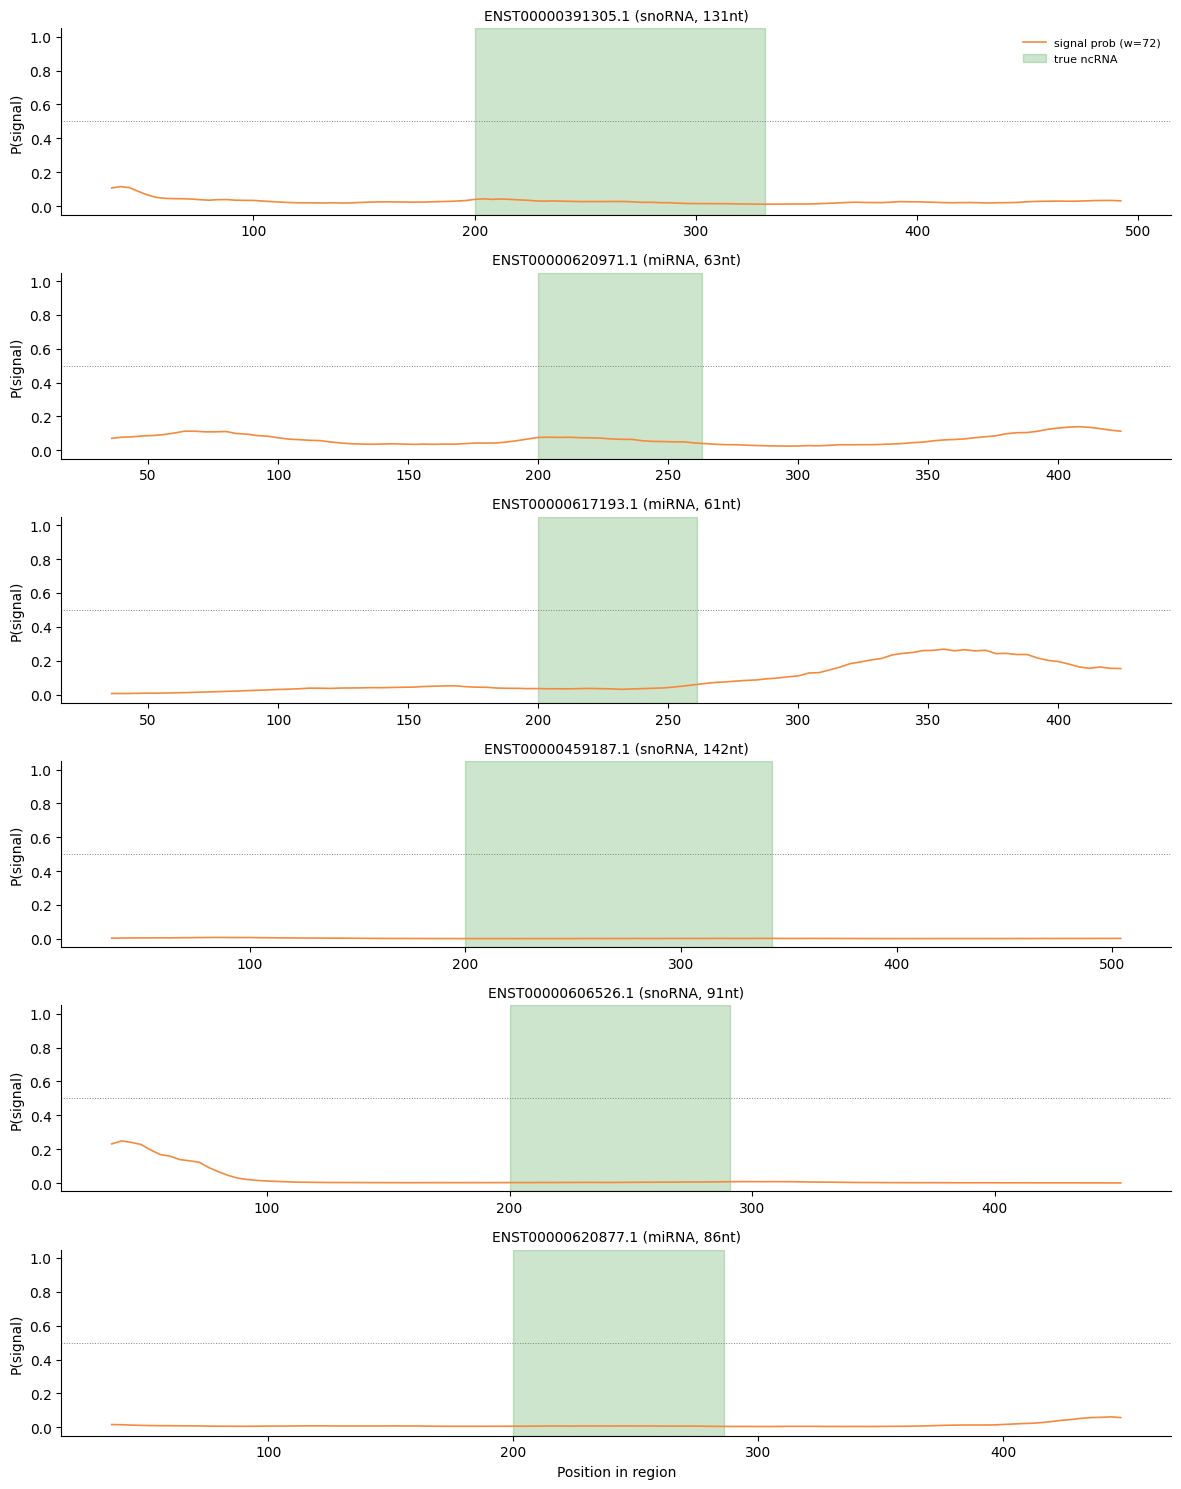

In [12]:
# --- Visualize a few example regions ---
n_show = min(6, len(test_regions))
best_ws = res_df.groupby("window")["recall"].mean().idxmax()  # best window size

fig, axes = plt.subplots(n_show, 1, figsize=(12, 2.5 * n_show), sharex=False)
if n_show == 1:
    axes = [axes]

for ax_i, reg in enumerate(test_regions[:n_show]):
    ax = axes[ax_i]
    full_emb = emb_rinalmo(reg["full_seq"])
    positions, probs = score_region(full_emb, pca_chosen, lr_chosen, best_ws)

    ax.plot(positions, probs, color="C1", lw=1.2, label=f"signal prob (w={best_ws})")
    ax.axhline(0.5, color="grey", ls=":", lw=0.7)
    ax.axvspan(reg["core_start"], reg["core_end"], alpha=0.2, color="green", label="true ncRNA")

    runs = find_signal_runs(positions, probs, threshold=0.5, min_run=20)
    for rs, re_, mp in runs:
        ax.axvspan(rs, re_, alpha=0.15, color="red", label="detected run" if rs == runs[0][0] else None)

    ax.set_ylabel("P(signal)")
    ax.set_title(f"{reg['id']} ({reg['biotype']}, {reg['core_len']}nt)", fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    if ax_i == 0:
        ax.legend(frameon=False, fontsize=8, loc="upper right")

axes[-1].set_xlabel("Position in region")
plt.tight_layout(); plt.show()

## Summary

In [13]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print(f"\n1. PCA k selection:")
print(f"   Chosen k = {chosen_k} (AUC={chosen_auc:.4f}, var={chosen_var:.1%})")
print(f"   RNA-FM k=16 baseline: AUC={auc_fm:.4f}, var={var_fm:.1%}")
print(f"   RiNALMo raw (1280-dim): AUC={auc_raw:.4f}")

print(f"\n2. Embed-once signal run detection (window={best_ws}, stride={STRIDE}):")
best_sub = res_df[res_df.window == best_ws]
n_found = (best_sub.recall > 0.5).sum()
print(f"   Regions found (recall>0.5): {n_found}/{len(best_sub)}")
print(f"   Mean recall: {best_sub.recall.mean():.2f}")
print(f"   Mean core prob: {best_sub.mean_core_prob.mean():.3f}")
print(f"   Mean flank prob: {best_sub.mean_flank_prob.mean():.3f}")
print(f"   Mean separation: {best_sub.separation.mean():.3f}")

print(f"\n3. Implications:")
if chosen_auc >= auc_fm - 0.01:
    print(f"   RiNALMo PCA({chosen_k}) matches RNA-FM PCA(16) for window-level classification.")
else:
    print(f"   RiNALMo PCA({chosen_k}) is slightly worse than RNA-FM PCA(16).")
if n_found / len(best_sub) > 0.7:
    print(f"   Embed-once + run detection WORKS: finds ncRNAs in {n_found}/{len(best_sub)} regions.")
    print(f"   This could replace per-window re-embedding for island detection.")
else:
    print(f"   Embed-once + run detection needs tuning ({n_found}/{len(best_sub)} found).")
    print(f"   Consider: different threshold, wider smoothing, or per-token classification.")

SUMMARY

1. PCA k selection:
   Chosen k = 16 (AUC=0.9733, var=84.5%)
   RNA-FM k=16 baseline: AUC=0.9837, var=84.9%
   RiNALMo raw (1280-dim): AUC=0.9603

2. Embed-once signal run detection (window=72, stride=4):
   Regions found (recall>0.5): 0/20
   Mean recall: 0.02
   Mean core prob: 0.097
   Mean flank prob: 0.095
   Mean separation: 0.002

3. Implications:
   RiNALMo PCA(16) is slightly worse than RNA-FM PCA(16).
   Embed-once + run detection needs tuning (0/20 found).
   Consider: different threshold, wider smoothing, or per-token classification.


## Part 3: Per-token classifier

Instead of mean-pooling windows, classify each nucleotide position directly:
- Train on individual token embeddings (72k training examples from the 1000 windows)
- PCA-reduce each token → LogReg → P(signal) per position
- For embed-once regions: embed full region, PCA each token, score, find signal runs

This should transfer better to sliced embeddings because individual token
embeddings are context-stable (unlike mean-pooled distributions).

In [14]:
# --- Train per-token classifier ---
# Stack all per-token embeddings with labels
token_X = []
token_y = []
for i, emb in enumerate(rin_tok_embs):
    token_X.append(emb)  # (72, 1280)
    token_y.append(np.full(emb.shape[0], y[i]))  # all positions get the window label

token_X = np.vstack(token_X).astype(np.float32)  # (72000, 1280)
token_y = np.concatenate(token_y)  # (72000,)
print(f"Token-level data: {token_X.shape}, {token_y.sum():.0f} signal / {(1-token_y).sum():.0f} noise")

# PCA on token-level embeddings (use chosen_k from Part 1)
pca_tok = PCA(n_components=chosen_k).fit(token_X[train_idx.repeat(72)])
token_X_pca = pca_tok.transform(token_X)
print(f"PCA({chosen_k}) variance: {pca_tok.explained_variance_ratio_.sum():.3f}")

# Train/test split: use same window-level split, expanded to tokens
tok_train = np.concatenate([np.arange(i*72, (i+1)*72) for i in train_idx])
tok_test = np.concatenate([np.arange(i*72, (i+1)*72) for i in test_idx])

lr_tok = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
lr_tok.fit(token_X_pca[tok_train], token_y[tok_train])

auc_tok = roc_auc_score(token_y[tok_test], lr_tok.predict_proba(token_X_pca[tok_test])[:, 1])
print(f"Per-token AUC: {auc_tok:.4f}")

# Also check window-level AUC by majority vote
window_probs_tok = []
for i in range(len(all_seqs)):
    toks = token_X_pca[i*72:(i+1)*72]
    probs = lr_tok.predict_proba(toks)[:, 1]
    window_probs_tok.append(probs.mean())
window_probs_tok = np.array(window_probs_tok)
auc_window_from_tok = roc_auc_score(y[test_idx], window_probs_tok[test_idx])
print(f"Window-level AUC (mean of token probs): {auc_window_from_tok:.4f}")
print(f"  (compare: window-level PCA+LR AUC = {chosen_auc:.4f})")

Token-level data: (72000, 1280), 36000 signal / 36000 noise
PCA(16) variance: 0.563
Per-token AUC: 0.8883
Window-level AUC (mean of token probs): 0.9034
  (compare: window-level PCA+LR AUC = 0.9733)


In [15]:
# --- Apply per-token classifier to embed-once regions ---
SMOOTH_K = 11  # smoothing kernel size (positions)

def smooth(probs, k=SMOOTH_K):
    """Simple moving average smoothing."""
    if len(probs) < k:
        return probs
    kernel = np.ones(k) / k
    return np.convolve(probs, kernel, mode="same")

tok_result_rows = []
for ri, reg in enumerate(test_regions):
    full_emb = emb_rinalmo(reg["full_seq"])  # (L, 1280)
    full_pca = pca_tok.transform(full_emb)   # (L, k)
    per_pos_probs = lr_tok.predict_proba(full_pca)[:, 1]  # (L,)
    per_pos_smooth = smooth(per_pos_probs)

    positions = np.arange(len(per_pos_smooth))
    runs = find_signal_runs(positions, per_pos_smooth, threshold=0.5, min_run=20)

    core_s, core_e = reg["core_start"], reg["core_end"]
    core_len = core_e - core_s

    best_overlap = 0
    for rs, re_, mp in runs:
        overlap = max(0, min(re_, core_e) - max(rs, core_s))
        if overlap > best_overlap:
            best_overlap = overlap

    recall = best_overlap / core_len if core_len > 0 else 0
    core_mask = (positions >= core_s) & (positions < core_e)
    mean_core = per_pos_smooth[core_mask].mean() if core_mask.any() else float("nan")
    mean_flank = per_pos_smooth[~core_mask].mean() if (~core_mask).any() else float("nan")

    tok_result_rows.append({
        "id": reg["id"], "biotype": reg["biotype"],
        "core_len": core_len, "recall": recall,
        "n_runs": len(runs),
        "mean_core_prob": mean_core, "mean_flank_prob": mean_flank,
        "separation": mean_core - mean_flank,
    })

tok_res_df = pd.DataFrame(tok_result_rows)
n_found = (tok_res_df.recall > 0.5).sum()
print(f"Per-token signal run detection:")
print(f"  Found (recall>0.5): {n_found}/{len(tok_res_df)}")
print(f"  Mean recall: {tok_res_df.recall.mean():.2f}")
print(f"  Mean core prob: {tok_res_df.mean_core_prob.mean():.3f}")
print(f"  Mean flank prob: {tok_res_df.mean_flank_prob.mean():.3f}")
print(f"  Mean separation: {tok_res_df.separation.mean():.3f}")
print(f"\nPer region:")
for _, r in tok_res_df.iterrows():
    status = "FOUND" if r.recall > 0.5 else "miss"
    print(f"  {r.id:>25s} ({r.biotype:>6s} {r.core_len:>3.0f}nt): "
          f"recall={r.recall:.2f} core={r.mean_core_prob:.3f} flank={r.mean_flank_prob:.3f} [{status}]")

Per-token signal run detection:
  Found (recall>0.5): 4/20
  Mean recall: 0.22
  Mean core prob: 0.399
  Mean flank prob: 0.357
  Mean separation: 0.042

Per region:
          ENST00000391305.1 (snoRNA 131nt): recall=0.00 core=0.220 flank=0.282 [miss]
          ENST00000620971.1 ( miRNA  63nt): recall=0.54 core=0.536 flank=0.394 [FOUND]
          ENST00000617193.1 ( miRNA  61nt): recall=0.05 core=0.380 flank=0.461 [miss]
          ENST00000459187.1 (snoRNA 142nt): recall=0.00 core=0.123 flank=0.173 [miss]
          ENST00000606526.1 (snoRNA  91nt): recall=0.00 core=0.166 flank=0.259 [miss]
          ENST00000620877.1 ( miRNA  86nt): recall=0.00 core=0.155 flank=0.179 [miss]
          ENST00000577388.1 ( miRNA  62nt): recall=1.00 core=0.660 flank=0.615 [FOUND]
          ENST00000384869.1 ( miRNA  67nt): recall=0.00 core=0.496 flank=0.462 [miss]
          ENST00000611346.1 ( miRNA  71nt): recall=0.10 core=0.430 flank=0.440 [miss]
          ENST00000385070.3 ( miRNA  76nt): recall=1.00 co

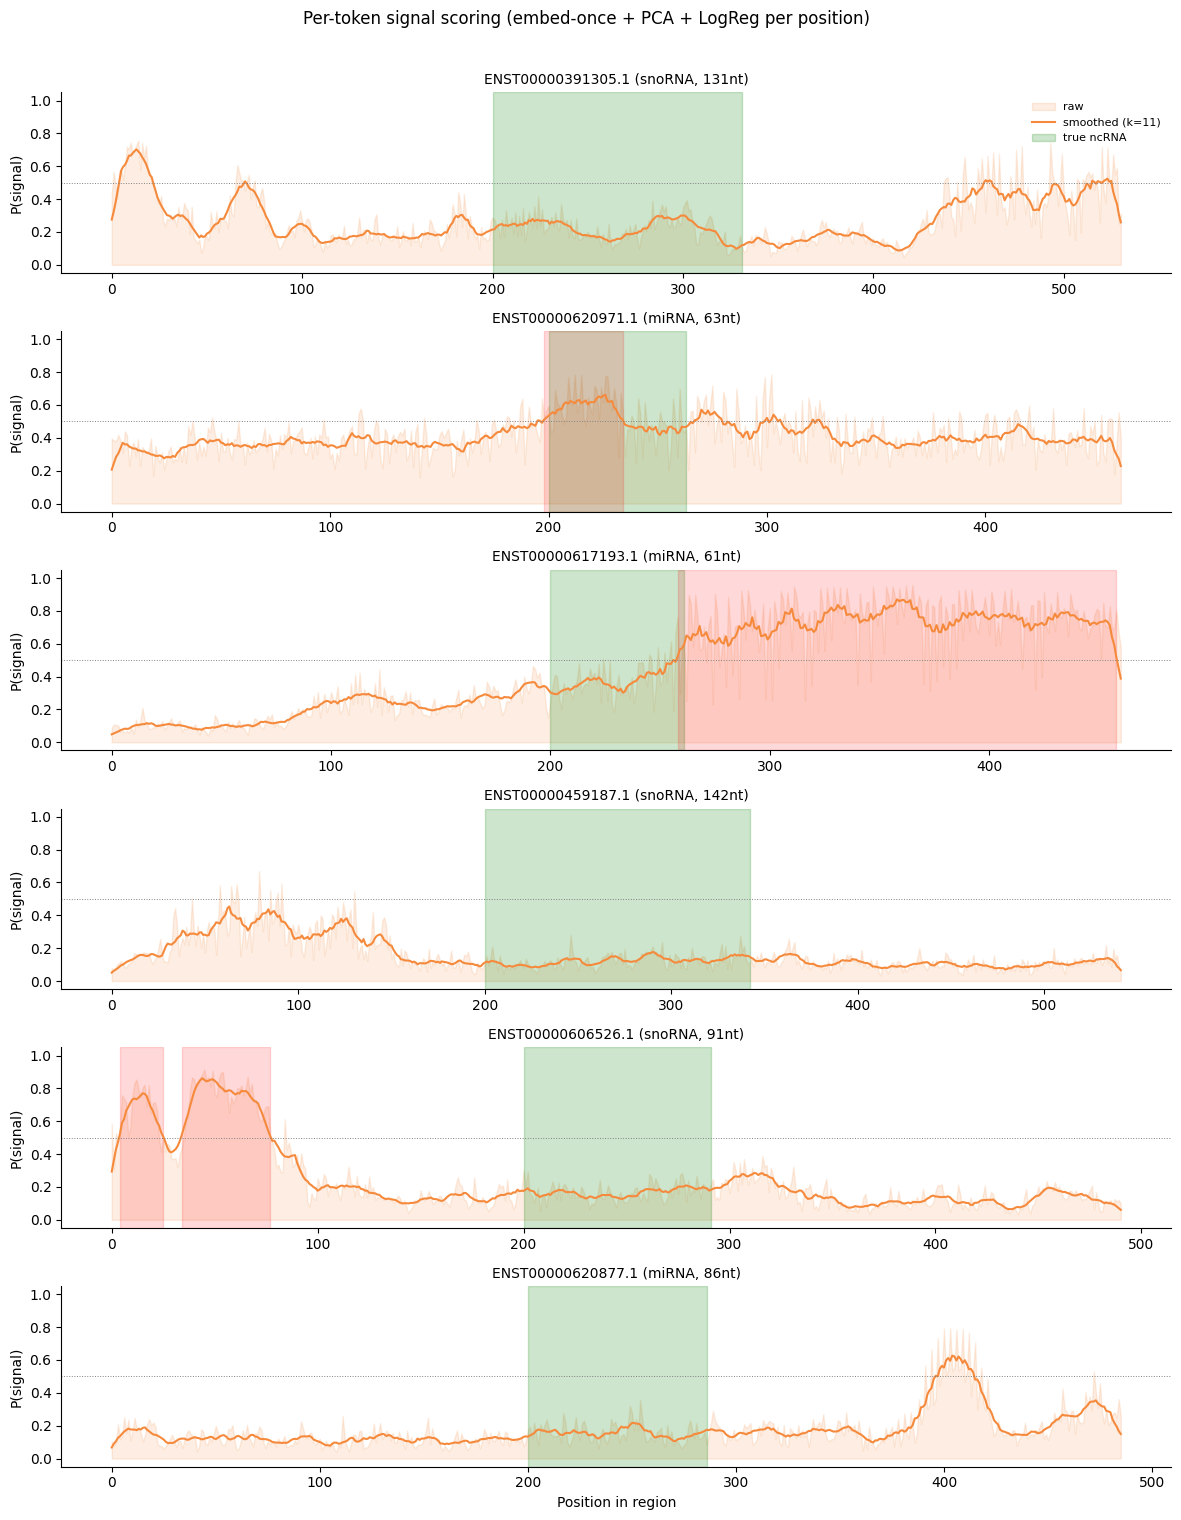

In [17]:
# --- Visualize per-token signal traces ---
n_show = min(6, len(test_regions))

fig, axes = plt.subplots(n_show, 1, figsize=(12, 2.5 * n_show), sharex=False)
if n_show == 1:
    axes = [axes]

for ax_i, reg in enumerate(test_regions[:n_show]):
    ax = axes[ax_i]
    full_emb = emb_rinalmo(reg["full_seq"])
    full_pca = pca_tok.transform(full_emb)
    raw_probs = lr_tok.predict_proba(full_pca)[:, 1]
    smoothed = smooth(raw_probs)

    positions = np.arange(len(raw_probs))
    ax.fill_between(positions, raw_probs, alpha=0.15, color="C1", label="raw")
    ax.plot(positions, smoothed, color="C1", lw=1.5, label=f"smoothed (k={SMOOTH_K})")
    ax.axhline(0.5, color="grey", ls=":", lw=0.7)
    ax.axvspan(reg["core_start"], reg["core_end"], alpha=0.2, color="green", label="true ncRNA")

    runs = find_signal_runs(positions, smoothed, threshold=0.5, min_run=20)
    for rs, re_, mp in runs:
        ax.axvspan(rs, re_, alpha=0.15, color="red", label="detected" if rs == runs[0][0] else None)

    ax.set_ylabel("P(signal)")
    ax.set_title(f"{reg['id']} ({reg['biotype']}, {reg['core_len']}nt)", fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    if ax_i == 0:
        ax.legend(frameon=False, fontsize=8, loc="upper right")

axes[-1].set_xlabel("Position in region")
plt.suptitle("Per-token signal scoring (embed-once + PCA + LogReg per position)", y=1.01)
plt.tight_layout(); plt.show()